### Pseudo-OHLC Data Generation

We can generate synthetic OHLC chart and use this fake chart to train our model

### Here a real chart of BTCUSDT at random hour

In [17]:
import pandas as pd
from dataWorker import *

start,end,duration,df = getRandomIntervalData('BTCUSDT',125, normalize=True)

df.to_parquet(f"data/real/btcusdt_{duration}_{start}_{end}.parquet", index=False)

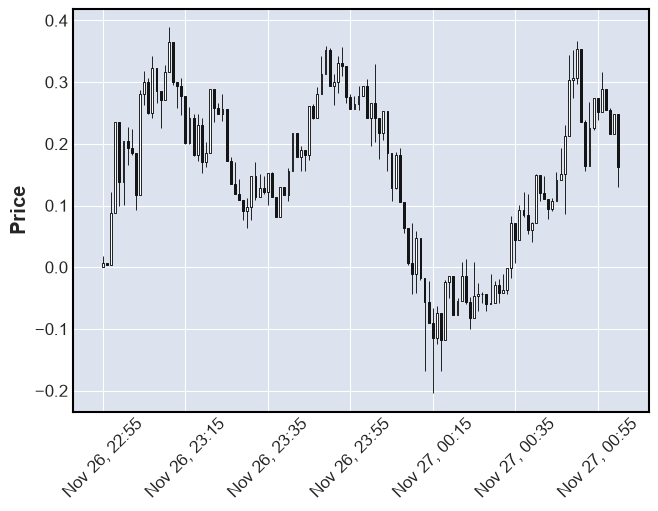

In [18]:
import mplfinance as mpf

#index
df = df.set_index("timestamp")
# plotting
mpf.plot(df, type='candle')


### Here we generate synthetic chart

Using _**Gaussian Distribution**_ for candle body generation and _**Student's t-distribution**_ for wick is best way to generate synthetic chart

In [19]:
from generator import generateSyntheticChart

df, seed = generateSyntheticChart(125)

Seed: 175622


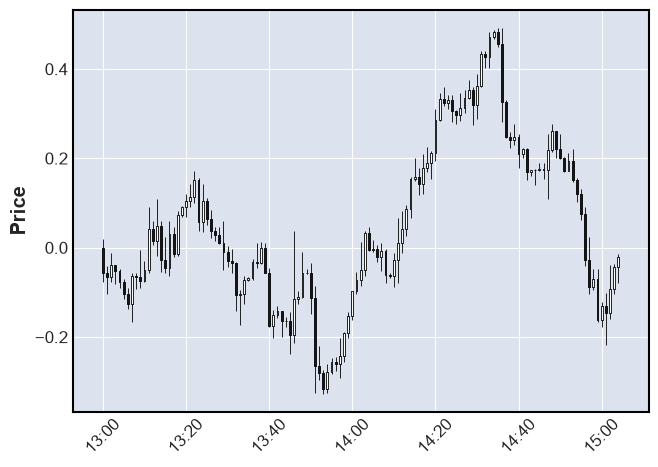

In [20]:
import pandas as pd
import mplfinance as mpf

df["timestamp"] = pd.to_datetime(df["timestamp"].astype("int64"), unit="ms")
#index
df = df.set_index("timestamp")
# plotting
print(f"Seed: {seed}")
mpf.plot(df, type='candle')

In [ ]:
from generator import generateSyntheticChart, saveDataSet
import pandas as pd
from tqdm import tqdm

qty = 8000

dtset = []
for i in tqdm(qty):
    df,seed = generateSyntheticChart( 125 )
    
    dtset.append([df, seed])
    
print(f"Generated {len(dtset)} charts")
saveDataSet(dtset, 'data/synthetic/0046_002_4_5')

Generated 8000 charts


AttributeError: 'list' object has no attribute 'to_parquet'